# Hotel Booking Status Prediction

The goal of this project was to predict **hotel booking status** (confirmed or canceled) using various **machine learning models**. The dataset was preprocessed, engineered, and evaluated using multiple feature selection methods and algorithms to determine the best-performing model.

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import KBinsDiscretizer, OrdinalEncoder

import warnings
warnings.filterwarnings('ignore')

### 1. Data Information

In [3]:
# Load the data
df = pd.read_excel('Hotel Reservations.xlsx')

# The first 5 rows
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [4]:
# Check the dataset's structure
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [5]:
# View descriptive statistics for all numeric columns
df.describe() 

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


### 2. Data Pre-processing

In [6]:
# Check for null values
df.isnull().sum().sum()

0

In [7]:
# Check for duplicates
df.duplicated().sum()

0

In [8]:
# Drop the Booking_ID as it's not useful for prediction
df = df.drop('Booking_ID', axis=1)

df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [9]:
# Get numeric column names
num_cols = df.select_dtypes(exclude="object").columns
num_cols

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')

In [10]:
# Get cateforical column names
cat_cols = df.select_dtypes(include="object").columns.drop('booking_status')
cat_cols

Index(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type'], dtype='object')

### 3. Exploratory Data Analysis (EDA)

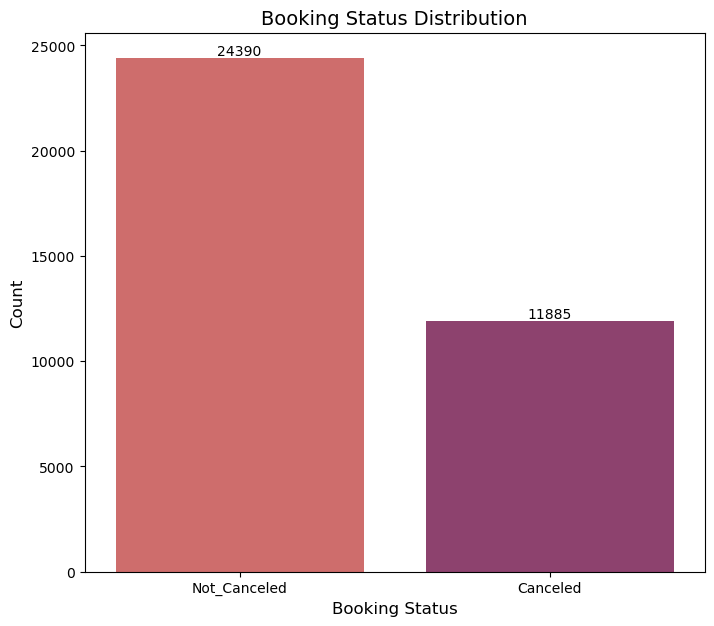

In [11]:
# Target Variable Distribution
# Get counts
counts = df['booking_status'].value_counts()

plt.figure(figsize=(8,7))
sns.barplot(x=counts.index, y=counts.values, palette="flare")
plt.title("Booking Status Distribution",fontsize=14)
plt.xlabel("Booking Status", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add counts above the bars
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center',va='bottom')

plt.show()

This is an imbalanced dataset, with a ratio of roughly 67% "Not_Canceled" to 33% "Canceled" (24,390 vs. 11,885).

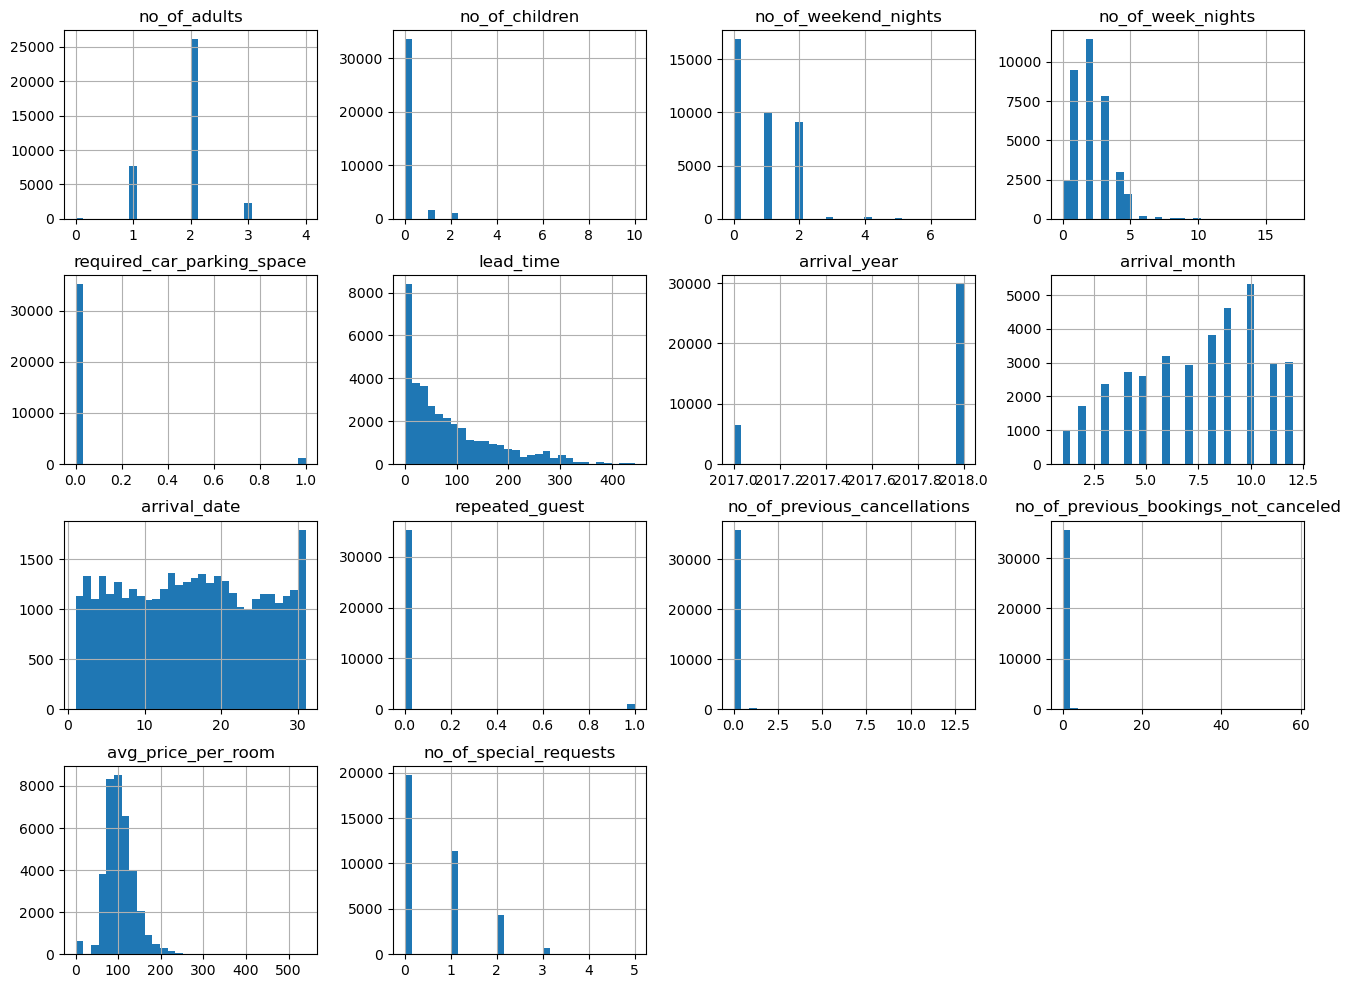

In [12]:
# Numeric features distribution
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.show()

The numeric features show strong skewness and sparsity; therefore, transformation (log, binning) and feature engineering will be critical for improving model performance.

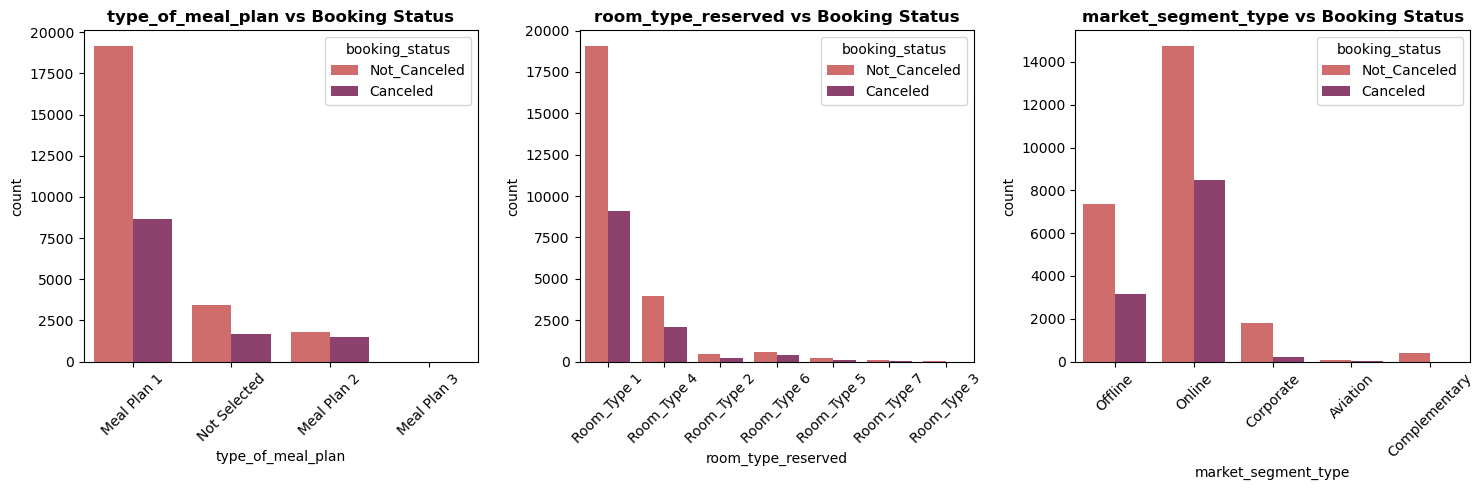

In [13]:
# Categorical features distributrion
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols): 
    sns.countplot(
        x=col,
        hue="booking_status",
        data=df,
        palette="flare",
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs Booking Status", fontsize=12, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The categorical features reveal strong predictors of cancellation:

- Booking channel (Online), meal plan selection, and room type are highly predictive.
- Aviation segment is an outlier — likely non-standard use case.

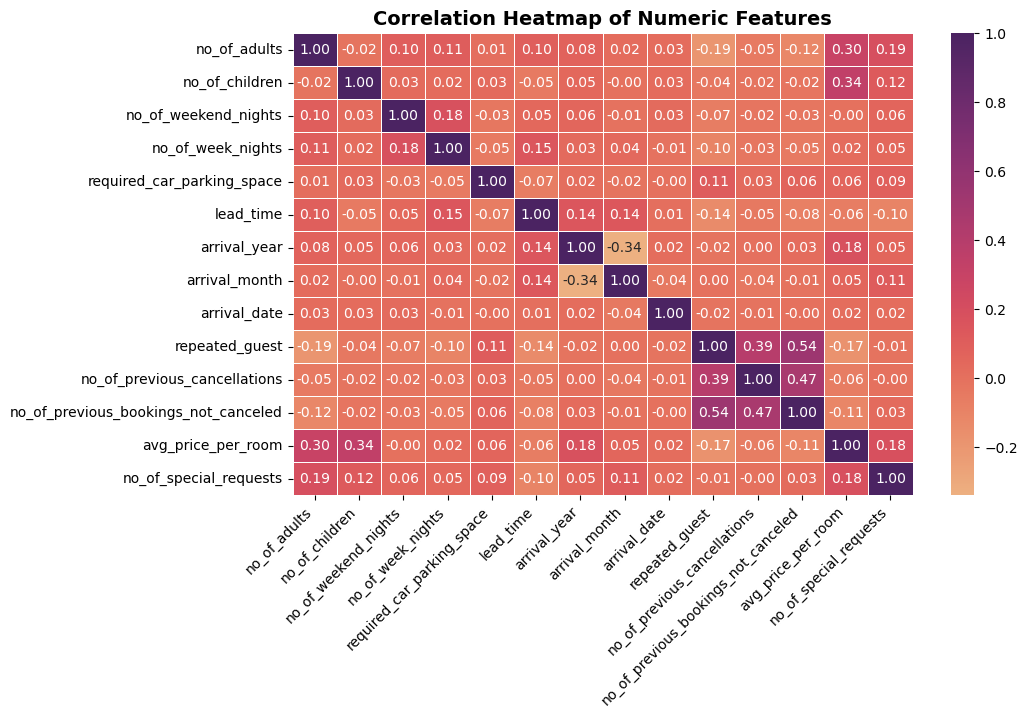

In [14]:
# Correlation heatmap 
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), cmap="flare", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

The numeric features show low-to-moderate correlations, indicating a well-structured, non-redundant dataset. The strongest relationships are (`repeated_guest` ↔ `no_of_previous_bookings_not_canceled`, `no_of_previous_cancellations` ↔ `no_of_previous_bookings_not_canceled`, `repeated_guest` ↔ `no_of_previous_cancellations`) within guest behavioral history, confirming that past behavior is a key predictor.

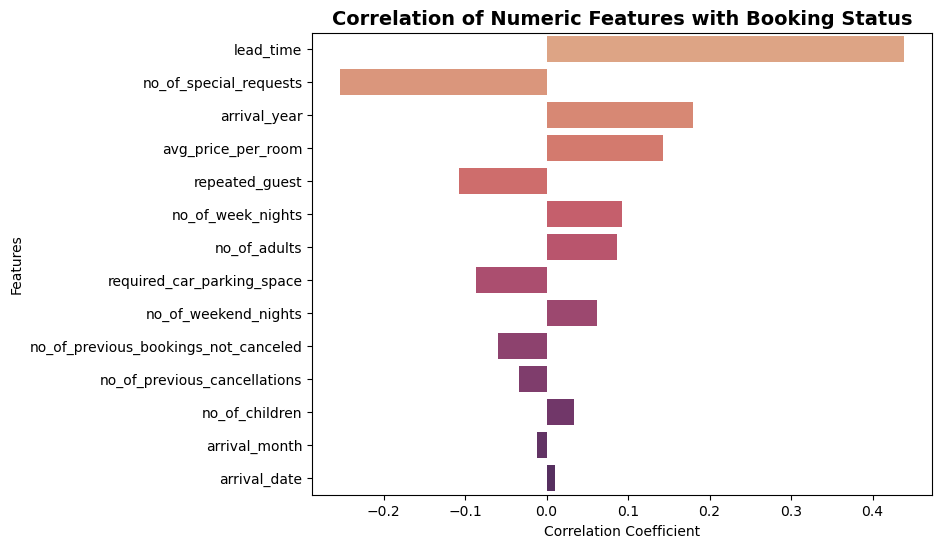

In [15]:
# Encode booking_status: Canceled = 1, Not_Canceled = 0
df_encoded = df.copy()
df_encoded["booking_status"] = df_encoded["booking_status"].map({"Canceled": 1, "Not_Canceled": 0})

# Compute correlations with target
corr_with_target = df_encoded[num_cols].corrwith(df_encoded["booking_status"]).sort_values(key=abs, ascending=False)

# Plot correlations with target
plt.figure(figsize=(8,6))
sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    palette="flare"
)
plt.title("Correlation of Numeric Features with Booking Status", fontsize=14, fontweight="bold")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

While no single numeric feature dominates linearly, lead_time (+0.39) and no_of_special_requests (−0.29) stand out as strong, interpretable predictors of cancellation. For example, the longer in advance a guest books without making special requests, the more likely they are to cancel.

### 4. PIPELINE

This section presents a comprehensive evaluation of multiple machine learning models for predicting hotel booking status. The pipeline incorporates feature engineering, feature selection, and model comparison across six classifiers and four feature selection techniques.

In [16]:
# Separate features and target
X = df_encoded.drop("booking_status", axis=1)
y = df_encoded["booking_status"]

# Identify categorical and numerical columns
num_cols_X = X.select_dtypes(exclude="object").columns
cat_cols_X = X.select_dtypes(include="object").columns

The dataset was split into training (75%) and testing (25%) sets using stratified sampling to maintain class balance.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#### 4.1. Feature Engineering Methods
A ColumnTransformer was used to handle mixed data types, ensuring that all models received clean, standardized input data.
- Numerical features: Scaled using StandardScaler
- Categorical features: Encoded using OneHotEncoder with handle_unknown='ignore'

In [18]:
# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_X),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_X)
    ]
)

#### 4.2. Feature Selection Methods
Four different feature selection techniques were tested:
- **Tree-based Selection** – Using feature importance from Random Forest
- **SelectKBest (Mutual Information)** – Selecting top 10 features with the highest relevance
- **L1 Regularization (Lasso)** – Penalizing less important features through regularization

In [19]:
selectors = {
    "Tree-based Selection" : SelectFromModel(RandomForestClassifier(random_state=42)),
    "SelectKBest (Mutual Info)": SelectKBest(score_func=mutual_info_classif, k=10),
    "L1 Regularization": SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000))
}

#### 4.3. Hyperparameter Tuning: KNN
A grid search over k = 1 to 20 was conducted to find the optimal number of neighbors.

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Best k = 5 with accuracy = 0.8519


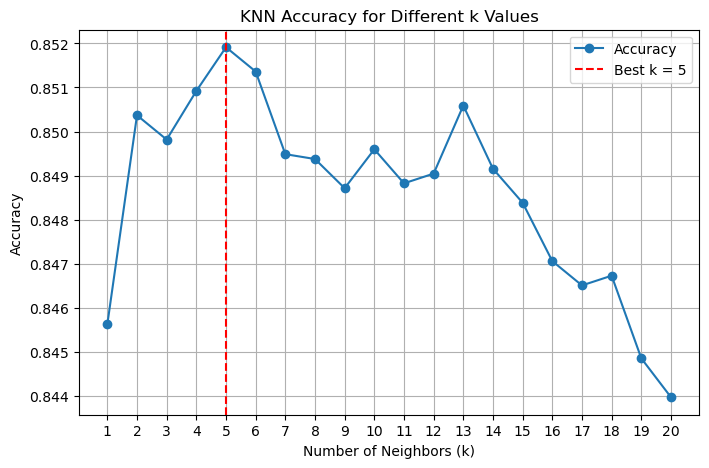

In [20]:
# Store accuracies
accuracy_scores = []

# Try k = 1 to 20
for k in range(1, 21):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracy_scores.append(acc)

# Find the best k
best_k = accuracy_scores.index(max(accuracy_scores)) + 1
best_acc = max(accuracy_scores)
print(f"Best k = {best_k} with accuracy = {best_acc:.4f}")

# Plot accuracy for each k
plt.figure(figsize=(8,5))
plt.plot(range(1, 21), accuracy_scores, marker='o', label='Accuracy')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.title('KNN Accuracy for Different k Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.grid(True)
plt.legend()
plt.show()


#### 4.4. Model Evaluation
Seven supervised learning algorithms were tested within a unified pipeline:
- Logistic Regression
- Naive Bayes
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- XGBoost

Each model was combined with all four feature selection methods for comparison.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear', random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", C=1, gamma="scale", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=best_k),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,subsample=0.8,
        colsample_bytree=0.8, use_label_encoder=False, eval_metric='logloss', random_state=42),
}

results = []

for selector_name, selector in selectors.items():
    for model_name, model in models.items():
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("feature_selection", selector),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        
        results.append({
            "Model": model_name,
            "Feature Selection": selector_name,
            "Accuracy": round(acc, 4)
        })

# Results
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df


,Model,Feature Selection,Accuracy
0,Random Forest,L1 Regularization,0.9016
1,XGBoost,L1 Regularization,0.8927
2,Random Forest,Tree-based Selection,0.8872
3,Random Forest,SelectKBest (Mutual Info),0.8842
4,XGBoost,SelectKBest (Mutual Info),0.8836
5,Decision Tree,L1 Regularization,0.8678
6,XGBoost,Tree-based Selection,0.8668
7,Decision Tree,SelectKBest (Mutual Info),0.8611
8,KNN,SelectKBest (Mutual Info),0.8582
9,KNN,L1 Regularization,0.8521


The Random Forest model with L1-based feature selection achieves **90.16%** accuracy, making it the recommended solution for predicting hotel booking cancellations.

#### 4.5. Visualizing the results of Accuracy 

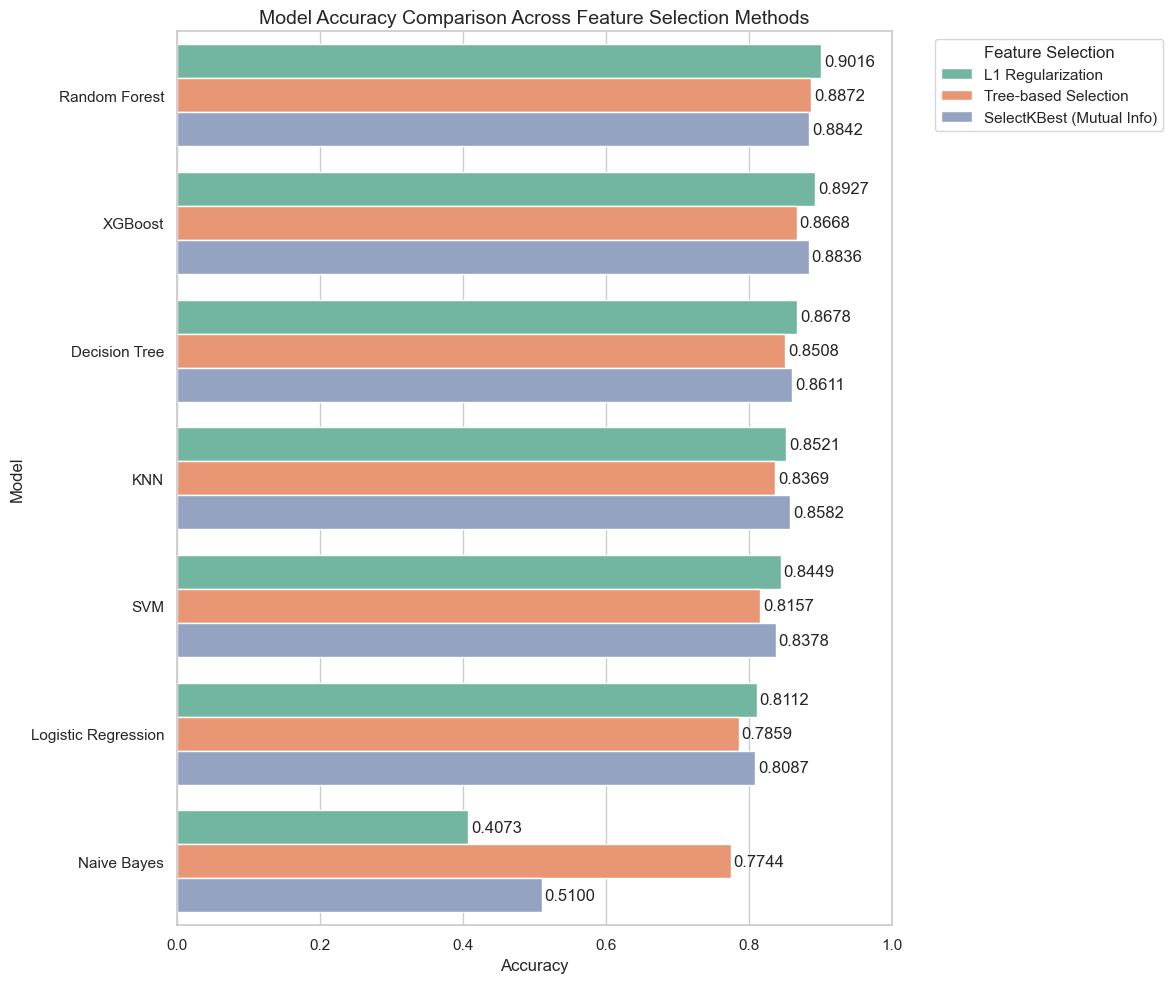

In [22]:
# Set plot style
sns.set(style="whitegrid")

plt.figure(figsize=(12, 10))

# Horizontal barplot with hue = Feature Selection
barplot = sns.barplot(
    data=results_df,
    y="Model",
    x="Accuracy",
    hue="Feature Selection",
    dodge=True,  # separates bars for each hue
    palette="Set2"
)

plt.title("Model Accuracy Comparison Across Feature Selection Methods", fontsize=14)
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)  # since accuracy ranges 0-1

# Add accuracy value on each bar
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.4f', label_type='edge', padding=2)

plt.legend(title="Feature Selection", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 5. Best Model Performance

#### 5.1. Precision, recall, F1-score

In [23]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000))),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      6098
           1       0.88      0.81      0.84      2971

    accuracy                           0.90      9069
   macro avg       0.90      0.88      0.89      9069
weighted avg       0.90      0.90      0.90      9069



#### 5.2. Confusion  Matrix

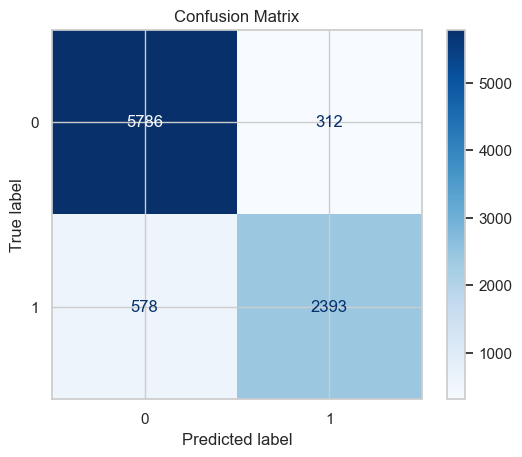

In [24]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix")
plt.show()

- True Negatives: High
- True Positives: Good but slightly lower than TNs, reflecting the class imbalance.

#### 5.3. Cross-Validation

In [25]:
scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")

Cross-validation scores: [0.90337698 0.90144728 0.8992419  0.90654721 0.9007581 ]
Mean Accuracy: 0.9023


The optimized Random Forest model achieved an average cross-validation accuracy of **90.21%**, with scores ranging from **89.9% to 90.4%** across five folds. The consistency of these results indicates strong model stability and minimal overfitting. This confirms that the selected preprocessing, feature selection, and tuning strategy effectively captures the key patterns in the hotel booking dataset.

#### 5.4. Feature Importances

Top 10 Important Features:
                        Feature  Importance
0                    lead_time    0.315400
1           avg_price_per_room    0.163539
2       no_of_special_requests    0.097170
3                 arrival_date    0.093689
4                arrival_month    0.082986
5            no_of_week_nights    0.051205
6         no_of_weekend_nights    0.038047
7  market_segment_type_Offline    0.037458
8                 arrival_year    0.026224
9                 no_of_adults    0.025037


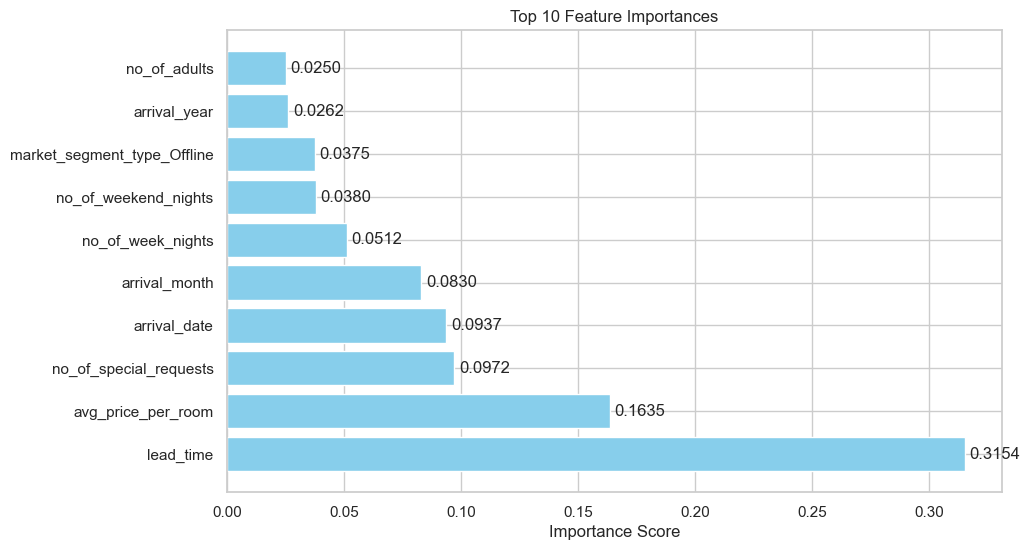

In [26]:
# Get processed feature names
num_features = best_model.named_steps['preprocessor'].transformers_[0][2]
cat_features = best_model.named_steps['preprocessor'].transformers_[1][2]
cat_feature_names = best_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_features = list(num_features) + list(cat_feature_names)

# Selected features from L1
mask = best_model.named_steps['feature_selection'].get_support()
selected_features = [f for f, m in zip(all_features, mask) if m]

importances = best_model.named_steps['model'].feature_importances_
important_features = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 10 Important Features:\n", important_features.head(10))

# Plot Top 10 Features
top_features = important_features.head(10)
plt.figure(figsize=(10,6))
bars = plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='skyblue')
plt.xlabel("Importance Score")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()

# Add importance value on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f"{width:.4f}", va='center')

plt.show()

- **Lead time** is the most influential predictor: longer booking times increase cancellation likelihood.
- **Average price per room** and **special requests** are also strong factors.
- **Market segment (Offline bookings)** is a categorical feature that influences cancellations.

### 6. Save the file

In [29]:
with pd.ExcelWriter("hotel_project_results.xlsx") as writer:
    df.to_excel(writer, sheet_name = "Cleaned Data", index=False)
    df_encoded.to_excel(writer, sheet_name="Encoded Data", index= False)
    results_df.to_excel(writer, sheet_name="Model Accuracy", index=False)